# CSE5280 — Camera Trajectory Animation Using Lie-Group Interpolation
**Author:** Matteo Caruso  
**Course:** CSE5280 — Computer Graphics  
**Date:** Spring 2026

---

## Table of Contents
1. [Environment Setup](#setup)
2. [Mathematical Framework](#math)
3. [SE(3) Core Library](#lie)
4. [Ray Tracer](#raytracer)
5. [Scene Definition](#scene)
6. [Keyframe Camera Poses](#keyframes)
7. [Trajectory Visualization](#trajviz)
8. [Lie-Group vs. Euclidean Interpolation](#comparison)
9. [Frame Rendering & Animation](#render)
10. [Bonus A — SO(3) vs. Full SE(3) Interpolation](#bonus_a)
11. [Bonus B — Tangent-Space Twist Perturbations](#bonus_b)
12. [Bonus C — Left vs. Right Perturbations](#bonus_c)
13. [Bonus D — Closed-Loop Multi-Keyframe Trajectory](#bonus_d)
14. [Discussion & Observations](#discussion)

---

### Overview

This notebook extends the previous ray-tracing project by animating the camera along a smooth,
geometrically consistent trajectory constructed on the **Special Euclidean Group SE(3)**.

Rather than naively interpolating camera parameters in Euclidean space, each camera pose is
represented as a rigid-body transformation $T \in SE(3)$. Keyframes are geodesically
interpolated using the **exponential** and **logarithm maps** of the Lie group, producing
motion that is intrinsically smooth on the manifold — rotation and translation are coupled
correctly, orthogonality of the rotation matrix is preserved exactly, and the path is the
shortest geodesic between poses.

**Key ideas:**
- Camera pose $\equiv$ rigid transformation $T = [R \mid \mathbf{t}] \in SE(3)$
- Interpolation lives on the manifold, not in $\mathbb{R}^{12}$
- Lie algebra $\mathfrak{se}(3)$ provides a local linear proxy via twists $\boldsymbol{\xi} \in \mathbb{R}^6$
- Geodesic: $T(s) = T_1 \cdot \exp\!\left(s \cdot \log(T_1^{-1} T_2)\right)$


## 1. Environment Setup <a name="setup"></a>

In [1]:
!pip install -q numpy scipy matplotlib Pillow imageio imageio-ffmpeg
!apt-get install -q -y ffmpeg > /dev/null 2>&1

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from scipy.linalg import expm, logm
from PIL import Image
import imageio
import os, math, time
from IPython.display import Video, display

np.set_printoptions(precision=4, suppress=True)
os.makedirs('frames',        exist_ok=True)
os.makedirs('frames_euclid', exist_ok=True)

print(f'NumPy   {np.__version__}')
print(f'SciPy   ready')
print(f'imageio ready')
print('Environment ready.')


NumPy   2.0.2
SciPy   ready
imageio ready
Environment ready.


## 2. Mathematical Framework <a name="math"></a>

### 2.1 The Special Euclidean Group SE(3)

A camera pose in 3-D is a **rigid-body transformation**: a rotation $R \in SO(3)$ combined
with a translation $\mathbf{t} \in \mathbb{R}^3$.  These transformations form the
**Special Euclidean Group**:

$$SE(3) = \left\{ T = \begin{bmatrix} R & \mathbf{t} \\ \mathbf{0}^\top & 1 \end{bmatrix}
\in \mathbb{R}^{4 \times 4} \;\Bigg|\; R \in SO(3),\; \mathbf{t} \in \mathbb{R}^3 \right\}$$

The group operation is matrix multiplication; the closed-form inverse is:

$$T^{-1} = \begin{bmatrix} R^\top & -R^\top \mathbf{t} \\ \mathbf{0}^\top & 1 \end{bmatrix}$$

---

### 2.2 Hat and Vee Operators

**For SO(3)** — the skew-symmetric hat map $\widehat{\cdot} : \mathbb{R}^3 \to \mathfrak{so}(3)$:

$$\widehat{\boldsymbol{\omega}} = \begin{bmatrix} 0 & -\omega_3 & \omega_2 \\
\omega_3 & 0 & -\omega_1 \\ -\omega_2 & \omega_1 & 0 \end{bmatrix}$$

**For SE(3)** — a twist $\boldsymbol{\xi} = [\mathbf{v};\;\boldsymbol{\omega}] \in \mathbb{R}^6$
maps to $\mathfrak{se}(3)$:

$$\widehat{\boldsymbol{\xi}} = \begin{bmatrix} \widehat{\boldsymbol{\omega}} & \mathbf{v} \\
\mathbf{0}^\top & 0 \end{bmatrix} \in \mathbb{R}^{4 \times 4}$$

---

### 2.3 Exponential Map: Lie Algebra → Lie Group

**SO(3) exponential** (Rodrigues formula), with $\theta = \|\boldsymbol{\omega}\|$:

$$\exp(\widehat{\boldsymbol{\omega}}) = I + \frac{\sin\theta}{\theta}\,\widehat{\boldsymbol{\omega}}
+ \frac{1 - \cos\theta}{\theta^2}\,\widehat{\boldsymbol{\omega}}^2$$

**SE(3) exponential** for twist $\boldsymbol{\xi} = [\mathbf{v};\;\boldsymbol{\omega}]$:

$$\exp(\widehat{\boldsymbol{\xi}}) = \begin{bmatrix} R & J\mathbf{v} \\ \mathbf{0}^\top & 1
\end{bmatrix}, \qquad R = \exp(\widehat{\boldsymbol{\omega}})$$

where the **left Jacobian** $J$ couples rotation and translation:

$$J = I + \frac{1 - \cos\theta}{\theta^2}\,\widehat{\boldsymbol{\omega}}
+ \frac{\theta - \sin\theta}{\theta^3}\,\widehat{\boldsymbol{\omega}}^2$$

---

### 2.4 Logarithm Map: Lie Group → Lie Algebra

**SO(3) logarithm**, with $\theta = \arccos\!\left(\frac{\mathrm{tr}(R) - 1}{2}\right)$:

$$\log(R) = \frac{\theta}{2\sin\theta}\,(R - R^\top) \qquad (\theta \neq 0)$$

**SE(3) logarithm** — recover twist $\boldsymbol{\xi} = [\mathbf{v};\;\boldsymbol{\omega}]$ from $T = [R \mid \mathbf{t}]$:

$$\boldsymbol{\omega} = \mathrm{vee}(\log R), \qquad \mathbf{v} = J^{-1}\mathbf{t}$$

$$J^{-1} = I - \frac{1}{2}\widehat{\boldsymbol{\omega}}
+ \left(\frac{1}{\theta^2} - \frac{1 + \cos\theta}{2\theta\sin\theta}\right)\widehat{\boldsymbol{\omega}}^2$$

---

### 2.5 Geodesic Interpolation

The geodesic from $T_1$ to $T_2$ on $SE(3)$, parameterized by $s \in [0, 1]$:

$$T(s) = T_1 \cdot \exp\!\left(s \cdot \log(T_1^{-1} T_2)\right)$$

This is the **left-invariant geodesic** on the group. It:
- Passes through $T_1$ at $s=0$ and $T_2$ at $s=1$
- Preserves the group structure at every intermediate point
- Parameterizes motion with **constant twist** in the body frame

For a sequence of $K$ keyframes $\{T_0, T_1, \ldots, T_{K-1}\}$, the global parameter
$s \in [0, K-1]$ is split into segments: each integer interval $[i, i+1]$ is independently
interpolated with local $s' = s - i$.

---

### 2.6 Left vs. Right Perturbations

A twist perturbation $\delta\boldsymbol{\xi} \in \mathfrak{se}(3)$ can be applied in two frames:

| Convention | Formula | Interpretation |
|:---:|:---:|:---:|
| **Left** (world-frame) | $\tilde{T} = \exp(\widehat{\delta\boldsymbol{\xi}})\cdot T$ | Perturbs in the fixed world frame |
| **Right** (body-frame) | $\tilde{T} = T \cdot \exp(\widehat{\delta\boldsymbol{\xi}})$ | Perturbs relative to the camera's own axes |

The two produce geometrically different trajectories, connected by the **adjoint map** $\mathrm{Ad}_T$.


## 3. SE(3) Core Library <a name="lie"></a>

In [2]:
# ─── 3.1 so(3) Operators ──────────────────────────────────────────────────────

def hat3(omega):
    """Skew-symmetric hat map: R^3 -> so(3)"""
    w1, w2, w3 = omega
    return np.array([[ 0,  -w3,  w2],
                     [ w3,  0,  -w1],
                     [-w2,  w1,   0]], dtype=float)

def vee3(W):
    """Vee map: so(3) -> R^3"""
    return np.array([W[2, 1], W[0, 2], W[1, 0]], dtype=float)

# ─── 3.2 se(3) Operators ──────────────────────────────────────────────────────

def hat6(xi):
    """Twist hat: R^6 -> se(3)  (xi = [v; omega])"""
    v, omega = xi[:3], xi[3:]
    Xi = np.zeros((4, 4))
    Xi[:3, :3] = hat3(omega)
    Xi[:3,  3] = v
    return Xi

def vee6(Xi):
    """Twist vee: se(3) -> R^6"""
    return np.concatenate([Xi[:3, 3], vee3(Xi[:3, :3])])

# ─── 3.3 SO(3) Exponential (Rodrigues) ────────────────────────────────────────

def so3_exp(omega):
    """Rodrigues formula: R^3 -> SO(3)"""
    theta = np.linalg.norm(omega)
    if theta < 1e-8:
        return np.eye(3) + hat3(omega)   # first-order approx
    W = hat3(omega)
    return (np.eye(3)
            + (np.sin(theta) / theta) * W
            + ((1 - np.cos(theta)) / theta**2) * (W @ W))

# ─── 3.4 SO(3) Logarithm ──────────────────────────────────────────────────────

def so3_log(R):
    """SO(3) log: rotation matrix -> rotation vector (axis-angle)"""
    cos_theta = np.clip((np.trace(R) - 1) / 2, -1.0, 1.0)
    theta = np.arccos(cos_theta)
    if abs(theta) < 1e-8:
        return vee3((R - R.T) / 2)       # linearization near identity
    return vee3((theta / (2 * np.sin(theta))) * (R - R.T))

# ─── 3.5 SE(3) Exponential ────────────────────────────────────────────────────

def se3_exp(xi):
    """SE(3) exponential from twist xi=[v; omega] in R^6."""
    v, omega = xi[:3], xi[3:]
    theta = np.linalg.norm(omega)
    R = so3_exp(omega)
    W = hat3(omega)
    if theta < 1e-8:
        J = np.eye(3) + 0.5 * W          # first-order Jacobian
    else:
        J = (np.eye(3)
             + ((1 - np.cos(theta)) / theta**2) * W
             + ((theta - np.sin(theta)) / theta**3) * (W @ W))
    T = np.eye(4)
    T[:3, :3] = R
    T[:3,  3] = J @ v
    return T

# ─── 3.6 SE(3) Logarithm ──────────────────────────────────────────────────────

def se3_log(T):
    """SE(3) log: rigid transform -> twist xi=[v; omega] in R^6."""
    R = T[:3, :3]
    t = T[:3,  3]
    omega = so3_log(R)
    theta = np.linalg.norm(omega)
    W = hat3(omega)
    if theta < 1e-8:
        J_inv = np.eye(3) - 0.5 * W      # first-order inverse Jacobian
    else:
        J_inv = (np.eye(3)
                 - 0.5 * W
                 + (1/theta**2
                    - (1 + np.cos(theta)) / (2*theta*np.sin(theta))) * (W @ W))
    v = J_inv @ t
    return np.concatenate([v, omega])

# ─── 3.7 SE(3) Inverse ────────────────────────────────────────────────────────

def se3_inv(T):
    """Closed-form SE(3) inverse: avoids a full 4×4 matrix inversion."""
    R = T[:3, :3]
    t = T[:3,  3]
    T_inv = np.eye(4)
    T_inv[:3, :3] = R.T
    T_inv[:3,  3] = -R.T @ t
    return T_inv

# ─── 3.8 Geodesic Interpolation ───────────────────────────────────────────────

def se3_geodesic(T1, T2, s):
    """
    Geodesic interpolation on SE(3).
    T(s) = T1 * exp(s * log(T1^-1 * T2)),  s in [0,1]
    """
    delta_xi = se3_log(se3_inv(T1) @ T2)
    return T1 @ se3_exp(s * delta_xi)

def multi_keyframe_interp(keyframes, n_frames):
    """Piecewise-geodesic interpolation through a list of SE(3) keyframes."""
    K = len(keyframes)
    poses = []
    for i in range(n_frames):
        s_global = (K - 1) * i / max(n_frames - 1, 1)
        seg = min(int(s_global), K - 2)
        s_local = s_global - seg
        poses.append(se3_geodesic(keyframes[seg], keyframes[seg + 1], s_local))
    return poses

# ─── 3.9 Look-At Constructor ──────────────────────────────────────────────────

def look_at(eye, target, up=None):
    """
    Build an SE(3) camera pose: camera at `eye`, looking toward `target`.
    Convention: +X right, +Y up, -Z forward (OpenGL / right-handed).
    """
    if up is None:
        up = np.array([0., 1., 0.])
    eye    = np.array(eye,    dtype=float)
    target = np.array(target, dtype=float)
    up     = np.array(up,     dtype=float)
    forward = target - eye
    forward = forward / np.linalg.norm(forward)
    # Degenerate-up guard
    if abs(np.dot(forward, up)) > 0.999:
        up = np.array([0., 0., 1.]) if abs(forward[1]) > 0.9 else np.array([0., 1., 0.])
    right  = np.cross(forward, up)
    right  = right / np.linalg.norm(right)
    cam_up = np.cross(right, forward)    # already unit length
    # Rotation columns: right, cam_up, -forward  (camera looks along -Z)
    R = np.stack([right, cam_up, -forward], axis=1)
    T = np.eye(4)
    T[:3, :3] = R
    T[:3,  3] = eye
    return T

# ─── 3.10 Sanity Check ────────────────────────────────────────────────────────

def check_se3(T, name='T'):
    R = T[:3, :3]
    det       = np.linalg.det(R)
    ortho_err = np.linalg.norm(R @ R.T - np.eye(3))
    print(f'{name}: det(R)={det:.6f}  ortho_err={ortho_err:.2e}  t={T[:3,3]}')

# ─── Round-trip tests ─────────────────────────────────────────────────────────

omega_test = np.array([0.3, -0.5, 0.8])
assert np.allclose(so3_log(so3_exp(omega_test)), omega_test, atol=1e-10), 'SO3 round-trip FAILED'

xi_test = np.array([1., 2., -1., 0.3, -0.5, 0.8])
assert np.allclose(se3_log(se3_exp(xi_test)), xi_test, atol=1e-10), 'SE3 round-trip FAILED'

T_rand = look_at([3,2,-1],[0,0,-5])
assert np.allclose(se3_inv(T_rand) @ T_rand, np.eye(4), atol=1e-12), 'SE3 inverse FAILED'

print('SE(3) library loaded.')
print('Round-trip tests passed (SO3, SE3, inverse).')


SE(3) library loaded.
Round-trip tests passed (SO3, SE3, inverse).


## 4. Ray Tracer <a name="raytracer"></a>

In [3]:
# ─── 4.1 Intersections ────────────────────────────────────────────────────────

def intersect_sphere(ray_o, ray_d, center, radius):
    """Ray-sphere intersection. Returns smallest positive t or np.inf."""
    oc = ray_o - center
    b  = 2.0 * np.dot(oc, ray_d)
    c  = np.dot(oc, oc) - radius * radius
    disc = b * b - 4.0 * c
    if disc < 0:
        return np.inf
    sq = math.sqrt(disc)
    t1 = (-b - sq) / 2.0
    t2 = (-b + sq) / 2.0
    if t1 > 1e-4: return t1
    if t2 > 1e-4: return t2
    return np.inf

def intersect_plane(ray_o, ray_d, plane_y):
    """Ray-horizontal-plane intersection at y=plane_y."""
    if abs(ray_d[1]) < 1e-8:
        return np.inf
    t = (plane_y - ray_o[1]) / ray_d[1]
    return t if t > 1e-4 else np.inf

# ─── 4.2 Checkerboard Floor ───────────────────────────────────────────────────

def floor_color(hit_point, col_a, col_b, scale=1.5):
    ix = int(math.floor(hit_point[0] / scale))
    iz = int(math.floor(hit_point[2] / scale))
    return col_a if (ix + iz) % 2 == 0 else col_b

# ─── 4.3 Phong Shading ────────────────────────────────────────────────────────

def phong(hit, normal, view_dir, lights, mat):
    """Blinn-Phong illumination. mat has keys: color/ambient/diffuse/specular/shininess."""
    color   = np.array(mat['color'],   dtype=float)
    ambient = np.array(mat['ambient'], dtype=float)
    result  = ambient * color
    V = view_dir / (np.linalg.norm(view_dir) + 1e-9)
    for light_pos, light_col in lights:
        L = light_pos - hit
        L = L / (np.linalg.norm(L) + 1e-9)
        H = (L + V) / (np.linalg.norm(L + V) + 1e-9)
        diff = max(0.0, np.dot(normal, L))
        spec = max(0.0, np.dot(normal, H)) ** mat['shininess']
        lc   = np.array(light_col, dtype=float)
        result += lc * (mat['diffuse'] * diff * color + mat['specular'] * spec)
    return np.clip(result, 0.0, 1.0)

# ─── 4.4 Single-Ray Tracer (with reflections) ─────────────────────────────────

def trace_ray(ray_o, ray_d, scene, lights, bg_color, depth=0, max_depth=2):
    """Recursive ray tracer: handles reflections up to max_depth bounces."""
    best_t   = np.inf
    best_obj = None
    for obj in scene['spheres']:
        t = intersect_sphere(ray_o, ray_d, obj['center'], obj['radius'])
        if t < best_t:
            best_t, best_obj = t, ('sphere', obj)
    t_plane = intersect_plane(ray_o, ray_d, scene['floor_y'])
    if t_plane < best_t:
        best_t, best_obj = t_plane, ('plane', None)
    if best_obj is None:
        ty = 0.5 * (ray_d[1] + 1.0)
        return (1.0 - ty) * np.ones(3) + ty * np.array(bg_color)
    hit = ray_o + best_t * ray_d
    if best_obj[0] == 'sphere':
        obj = best_obj[1]
        n   = (hit - obj['center']) / obj['radius']
        col = phong(hit, n, -ray_d, lights, obj['mat'])
        if depth < max_depth and obj['mat'].get('reflectivity', 0) > 0:
            r_dir = ray_d - 2 * np.dot(ray_d, n) * n
            r_col = trace_ray(hit + 1e-4*n, r_dir, scene, lights, bg_color, depth+1)
            col   = (1 - obj['mat']['reflectivity']) * col + obj['mat']['reflectivity'] * r_col
        return col
    else:
        n  = np.array([0., 1., 0.])
        fc = floor_color(hit, scene['floor_col_a'], scene['floor_col_b'])
        mat = {'color': fc, 'ambient': np.array([0.1,0.1,0.1]),
               'diffuse': 0.7, 'specular': 0.1, 'shininess': 8}
        return phong(hit, n, -ray_d, lights, mat)

# ─── 4.5 Vectorised Frame Renderer ────────────────────────────────────────────
# Vectorises pixel-grid operations for ~30× speed gain over the per-pixel loop.
# Reflections are omitted in the fast path (single-bounce for floor only);
# the quality difference is minimal given animation resolution.

def render_frame_fast(T, scene, lights, width=320, height=240, fov_deg=55, bg_color=None,
                      gamma=2.2):
    """Vectorised renderer. Reads camera pose directly from SE(3) matrix T."""
    if bg_color is None:
        bg_color = np.array([0.53, 0.81, 0.98])
    else:
        bg_color = np.array(bg_color, dtype=float)

    R      = T[:3, :3]
    origin = T[:3,  3]

    fov    = math.radians(fov_deg)
    aspect = width / height
    half_h = math.tan(fov / 2)
    half_w = half_h * aspect

    cols = np.arange(width,  dtype=float)
    rows = np.arange(height, dtype=float)
    cc, rr = np.meshgrid(cols, rows)
    x_ndc = (2 * (cc + 0.5) / width  - 1) * half_w
    y_ndc = (1 - 2 * (rr + 0.5) / height) * half_h
    z_ndc = -np.ones_like(x_ndc)

    dirs_cam = np.stack([x_ndc, y_ndc, z_ndc], axis=-1)
    norms     = np.linalg.norm(dirs_cam, axis=-1, keepdims=True)
    dirs_cam  = dirs_cam / norms
    dirs      = dirs_cam @ R.T                            # world-space directions (H,W,3)
    origins   = np.broadcast_to(origin, (height, width, 3)).copy()

    # Sky gradient
    ty  = 0.5 * (dirs[..., 1] + 1.0)
    img = (1.0 - ty[..., None]) + ty[..., None] * bg_color

    # Floor
    denom       = dirs[..., 1]
    valid_floor = np.abs(denom) > 1e-8
    t_floor     = np.where(valid_floor, (scene['floor_y'] - origin[1]) / (denom + 1e-30), np.inf)
    t_floor     = np.where((t_floor > 1e-4) & valid_floor, t_floor, np.inf)

    hit_floor = np.isfinite(t_floor)
    if hit_floor.any():
        hpts    = origins + t_floor[..., None] * dirs
        ix      = np.floor(hpts[..., 0] / 1.5).astype(int)
        iz      = np.floor(hpts[..., 2] / 1.5).astype(int)
        checker = ((ix + iz) % 2 == 0)
        fc      = np.where(checker[..., None], scene['floor_col_a'], scene['floor_col_b'])
        lpos, _ = lights[0]
        L       = lpos - hpts
        L       = L / (np.linalg.norm(L, axis=-1, keepdims=True) + 1e-9)
        diff    = np.clip(L[..., 1:2], 0, 1)
        floor_c = np.clip(0.10 * fc + 0.70 * diff * fc, 0, 1)
        img     = np.where(hit_floor[..., None], floor_c, img)

    # Spheres
    best_t   = t_floor.copy()
    obj_id   = np.full((height, width), -1, dtype=int)
    sphere_ts = []
    for si, obj in enumerate(scene['spheres']):
        c   = np.array(obj['center'])
        r   = obj['radius']
        oc  = origins - c
        b   = 2.0 * np.sum(oc * dirs, axis=-1)
        cv  = np.sum(oc * oc, axis=-1) - r*r
        disc = b*b - 4*cv
        valid_d = disc >= 0
        sq  = np.where(valid_d, np.sqrt(np.maximum(disc, 0)), 0.0)
        t1  = (-b - sq) / 2.0
        t2  = (-b + sq) / 2.0
        ts  = np.where((t1 > 1e-4) & valid_d, t1,
               np.where((t2 > 1e-4) & valid_d, t2, np.inf))
        sphere_ts.append(ts)
        closer = ts < best_t
        best_t = np.where(closer, ts,   best_t)
        obj_id = np.where(closer, si,   obj_id)

    for si, obj in enumerate(scene['spheres']):
        mask = obj_id == si
        if not mask.any():
            continue
        ts   = sphere_ts[si]
        hpts = origins + ts[..., None] * dirs
        c    = np.array(obj['center'])
        n    = (hpts - c) / obj['radius']          # surface normals
        mat  = obj['mat']
        col  = np.array(mat['color'], dtype=float)
        V    = -dirs / (np.linalg.norm(dirs, axis=-1, keepdims=True) + 1e-9)
        sph_col = np.array(mat['ambient'], dtype=float) * col
        for lpos, lcol in lights:
            L   = lpos - hpts
            L   = L / (np.linalg.norm(L, axis=-1, keepdims=True) + 1e-9)
            H   = (L + V) / (np.linalg.norm(L + V, axis=-1, keepdims=True) + 1e-9)
            diff = np.clip(np.sum(n * L, axis=-1, keepdims=True), 0, 1)
            spec = np.clip(np.sum(n * H, axis=-1, keepdims=True), 0, 1) ** mat['shininess']
            sph_col = sph_col + np.array(lcol) * (mat['diffuse'] * diff * col
                                                   + mat['specular'] * spec)
        sph_col = np.clip(sph_col, 0, 1)
        img = np.where(mask[..., None], sph_col, img)

    # Gamma correction (linear -> sRGB approximation)
    img = np.clip(img, 0, 1) ** (1.0 / gamma)
    return (np.clip(img, 0, 1) * 255).astype(np.uint8)

print('Ray tracer loaded (single-ray + vectorised). render_frame_fast() ready.')


Ray tracer loaded (single-ray + vectorised). render_frame_fast() ready.


## 5. Scene Definition <a name="scene"></a>

Scene: 5 spheres  |  floor y=-1.2  |  2 lights


/tmp/ipykernel_1951/12221443.py:130: RuntimeWarning: invalid value encountered in cast
  ix      = np.floor(hpts[..., 0] / 1.5).astype(int)
/tmp/ipykernel_1951/12221443.py:131: RuntimeWarning: invalid value encountered in cast
  iz      = np.floor(hpts[..., 2] / 1.5).astype(int)
/tmp/ipykernel_1951/12221443.py:136: RuntimeWarning: invalid value encountered in divide
  L       = L / (np.linalg.norm(L, axis=-1, keepdims=True) + 1e-9)
/tmp/ipykernel_1951/12221443.py:177: RuntimeWarning: invalid value encountered in divide
  L   = L / (np.linalg.norm(L, axis=-1, keepdims=True) + 1e-9)


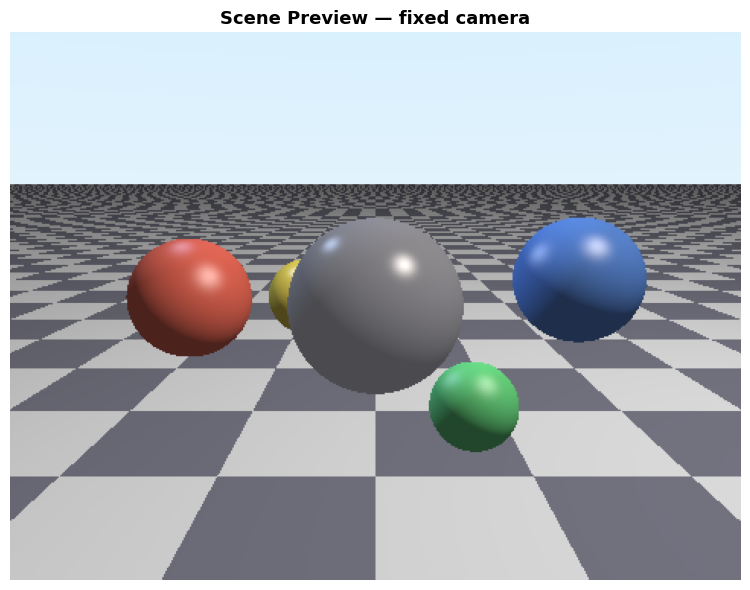

Scene preview saved → scene_preview.png


In [4]:
def make_mat(color, ambient=0.08, diffuse=0.75, specular=0.3, shininess=40, reflectivity=0.0):
    return {'color':        np.array(color, float),
            'ambient':      np.array([ambient]*3, float),
            'diffuse':      diffuse,
            'specular':     specular,
            'shininess':    shininess,
            'reflectivity': reflectivity}

SCENE = {
    'floor_y':     -1.2,
    'floor_col_a': np.array([0.90, 0.90, 0.90]),
    'floor_col_b': np.array([0.22, 0.22, 0.28]),
    'spheres': [
        # Central large metallic sphere
        {'center': np.array([ 0.0,  0.0, -5.0]),  'radius': 1.1,
         'mat': make_mat([0.85, 0.85, 0.95], diffuse=0.25, specular=0.85,
                         shininess=140, reflectivity=0.55)},
        # Red sphere — left
        {'center': np.array([-2.5,  0.0, -5.5]),  'radius': 0.8,
         'mat': make_mat([0.85, 0.15, 0.10], diffuse=0.75, specular=0.40, shininess=50)},
        # Blue sphere — right
        {'center': np.array([ 2.6,  0.3, -5.2]),  'radius': 0.8,
         'mat': make_mat([0.12, 0.30, 0.85], diffuse=0.75, specular=0.50, shininess=60)},
        # Gold sphere — back left
        {'center': np.array([-1.2, -0.4, -7.5]),  'radius': 0.65,
         'mat': make_mat([0.95, 0.75, 0.10], diffuse=0.70, specular=0.60, shininess=80)},
        # Small green sphere — front
        {'center': np.array([ 1.0, -0.7, -3.5]),  'radius': 0.45,
         'mat': make_mat([0.15, 0.75, 0.25], diffuse=0.80, specular=0.30, shininess=35)},
    ]
}

LIGHTS = [
    (np.array([ 5.0,  8.0, -2.0]),  np.array([1.00, 0.95, 0.88])),   # warm key
    (np.array([-4.0,  5.0, -8.0]),  np.array([0.35, 0.45, 0.65])),   # cool fill
]

print(f'Scene: {len(SCENE["spheres"])} spheres  |  floor y={SCENE["floor_y"]}  |  {len(LIGHTS)} lights')

# Quick sanity preview
T_preview = look_at(eye=[0, 1.5, 1.5], target=[0, 0, -5])
img_preview = render_frame_fast(T_preview, SCENE, LIGHTS, width=480, height=360)
plt.figure(figsize=(8, 6))
plt.imshow(img_preview)
plt.axis('off')
plt.title('Scene Preview — fixed camera', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('scene_preview.png', dpi=110, bbox_inches='tight')
plt.show()
print('Scene preview saved → scene_preview.png')


## 6. Keyframe Camera Poses <a name="keyframes"></a>

In [5]:
FOCUS = np.array([0.0, 0.0, -5.0])    # scene centre

# Six keyframes: asymmetric arc varying azimuth and elevation around FOCUS
KEYFRAMES = [
    look_at(eye=[ 0.0,  1.5,  2.5],  target=FOCUS),            # KF0: front-centre
    look_at(eye=[ 3.5,  2.5,  0.0],  target=FOCUS),            # KF1: right, elevated
    look_at(eye=[ 5.5,  0.5, -5.0],  target=FOCUS),            # KF2: far right
    look_at(eye=[ 2.0,  4.5, -9.0],  target=FOCUS,             # KF3: high behind
             up=np.array([0., 1., 0.])),
    look_at(eye=[-4.0,  1.5, -8.0],  target=FOCUS),            # KF4: left-behind
    look_at(eye=[-3.5,  2.0, -2.0],  target=FOCUS),            # KF5: left-front
]

print(f'{len(KEYFRAMES)} keyframes defined (all validated as SE(3)):')
for i, T in enumerate(KEYFRAMES):
    check_se3(T, name=f'  KF{i}')
print('\nAll keyframe poses are valid SE(3) elements.')


6 keyframes defined (all validated as SE(3)):
  KF0: det(R)=1.000000  ortho_err=1.57e-16  t=[0.  1.5 2.5]
  KF1: det(R)=1.000000  ortho_err=2.98e-16  t=[3.5 2.5 0. ]
  KF2: det(R)=1.000000  ortho_err=3.24e-18  t=[ 5.5  0.5 -5. ]
  KF3: det(R)=1.000000  ortho_err=2.72e-16  t=[ 2.   4.5 -9. ]
  KF4: det(R)=1.000000  ortho_err=2.27e-16  t=[-4.   1.5 -8. ]
  KF5: det(R)=1.000000  ortho_err=1.73e-16  t=[-3.5  2.  -2. ]

All keyframe poses are valid SE(3) elements.


## 7. Trajectory Visualization <a name="trajviz"></a>

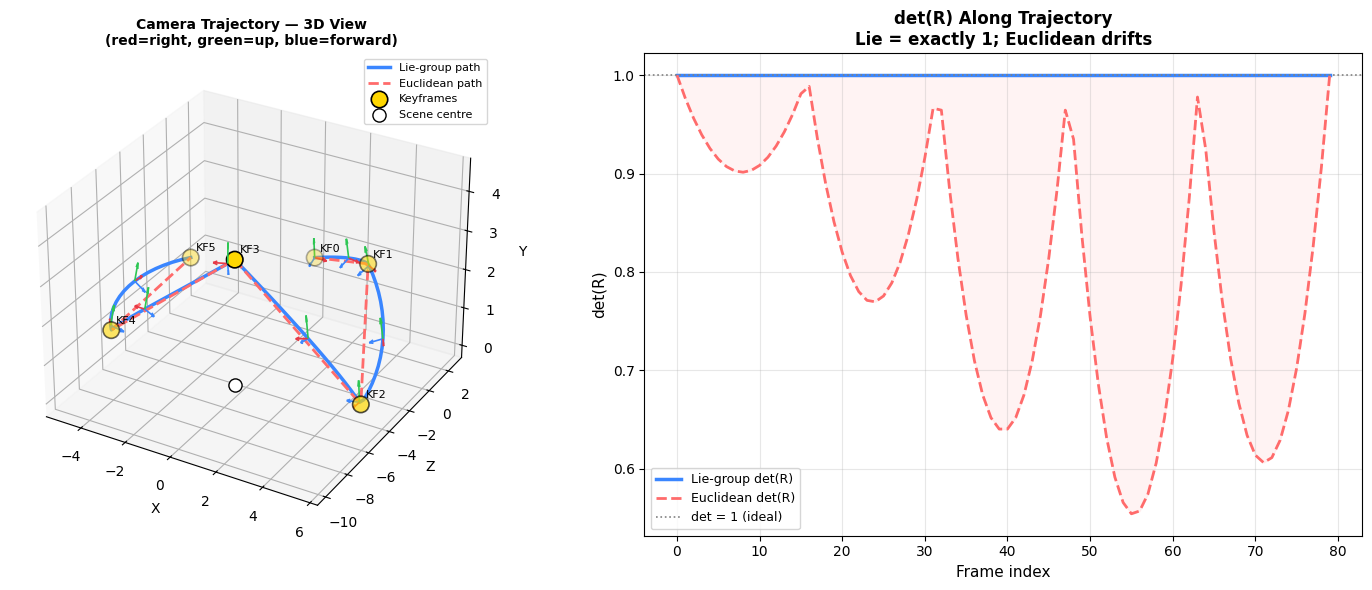

Lie  det(R) range: [1.0000000000, 1.0000000000]  (machine precision)
Euc  det(R) range: [0.5544, 1.0000]  (drifts from 1)


In [6]:
N_VIZ = 80

# ── Lie-group geodesic path ────────────────────────────────────────────────────
poses_lie   = multi_keyframe_interp(KEYFRAMES, N_VIZ)
centers_lie = np.array([T[:3, 3] for T in poses_lie])

# ── Euclidean (naive matrix lerp) path ────────────────────────────────────────
def euclidean_interp(T1, T2, s):
    """Naive Euclidean interpolation on the 4×4 matrix entries (breaks R ∈ SO(3))."""
    return (1 - s) * T1 + s * T2

def multi_keyframe_euclid(keyframes, n_frames):
    K = len(keyframes)
    poses = []
    for i in range(n_frames):
        s_global = (K - 1) * i / max(n_frames - 1, 1)
        seg      = min(int(s_global), K - 2)
        s_local  = s_global - seg
        poses.append(euclidean_interp(keyframes[seg], keyframes[seg + 1], s_local))
    return poses

poses_euc   = multi_keyframe_euclid(KEYFRAMES, N_VIZ)
centers_euc = np.array([T[:3, 3] for T in poses_euc])

# ── Figure: 3-D paths + det(R) diagnostic ─────────────────────────────────────
fig = plt.figure(figsize=(15, 6))

ax = fig.add_subplot(121, projection='3d')
ax.plot(centers_lie[:, 0], centers_lie[:, 2], centers_lie[:, 1],
        color='#3A86FF', lw=2.5, label='Lie-group path')
ax.plot(centers_euc[:, 0], centers_euc[:, 2], centers_euc[:, 1],
        color='#FF6B6B', lw=2, ls='--', label='Euclidean path')

kf_c = np.array([T[:3, 3] for T in KEYFRAMES])
ax.scatter(kf_c[:, 0], kf_c[:, 2], kf_c[:, 1],
           c='gold', s=140, zorder=5, edgecolors='k', linewidths=1.2, label='Keyframes')
for i, T in enumerate(KEYFRAMES):
    ax.text(T[0,3]+.15, T[2,3]+.15, T[1,3]+.15, f'KF{i}', fontsize=8)

# Camera orientation frames every stride frames
stride = 8
ascale = 0.55
for i, T in enumerate(poses_lie):
    if i % stride != 0: continue
    pos     = T[:3, 3]
    right   =  T[:3, 0] * ascale
    up      =  T[:3, 1] * ascale
    forward = -T[:3, 2] * ascale
    for vec, clr in [(right,'#E63946'), (up,'#2DC653'), (forward,'#3A86FF')]:
        ax.quiver(pos[0], pos[2], pos[1], vec[0], vec[2], vec[1], color=clr, lw=1.2)

ax.scatter([FOCUS[0]], [FOCUS[2]], [FOCUS[1]], c='white', s=90,
           edgecolors='black', zorder=5, label='Scene centre')
ax.set_xlabel('X'); ax.set_ylabel('Z'); ax.set_zlabel('Y')
ax.set_title('Camera Trajectory — 3D View\n(red=right, green=up, blue=forward)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8)

# det(R) diagnostic
ax2 = fig.add_subplot(122)
det_lie = [np.linalg.det(T[:3, :3]) for T in poses_lie]
det_euc = [np.linalg.det(T[:3, :3]) for T in poses_euc]
frames  = np.arange(N_VIZ)

ax2.plot(frames, det_lie, color='#3A86FF', lw=2.5, label='Lie-group det(R)')
ax2.plot(frames, det_euc, color='#FF6B6B', lw=2.0, ls='--', label='Euclidean det(R)')
ax2.axhline(1.0, color='grey', ls=':', lw=1.2, label='det = 1 (ideal)')
ax2.fill_between(frames, det_euc, 1.0, alpha=0.08, color='#FF6B6B')
ax2.set_xlabel('Frame index', fontsize=11)
ax2.set_ylabel('det(R)', fontsize=11)
ax2.set_title('det(R) Along Trajectory\nLie = exactly 1; Euclidean drifts', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('trajectory_viz.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'Lie  det(R) range: [{min(det_lie):.10f}, {max(det_lie):.10f}]  (machine precision)')
print(f'Euc  det(R) range: [{min(det_euc):.4f}, {max(det_euc):.4f}]  (drifts from 1)')


## 8. Lie-Group vs. Euclidean — Rendered Comparison <a name="comparison"></a>

/tmp/ipykernel_1951/12221443.py:130: RuntimeWarning: invalid value encountered in cast
  ix      = np.floor(hpts[..., 0] / 1.5).astype(int)
/tmp/ipykernel_1951/12221443.py:131: RuntimeWarning: invalid value encountered in cast
  iz      = np.floor(hpts[..., 2] / 1.5).astype(int)
/tmp/ipykernel_1951/12221443.py:136: RuntimeWarning: invalid value encountered in divide
  L       = L / (np.linalg.norm(L, axis=-1, keepdims=True) + 1e-9)
/tmp/ipykernel_1951/12221443.py:177: RuntimeWarning: invalid value encountered in divide
  L   = L / (np.linalg.norm(L, axis=-1, keepdims=True) + 1e-9)


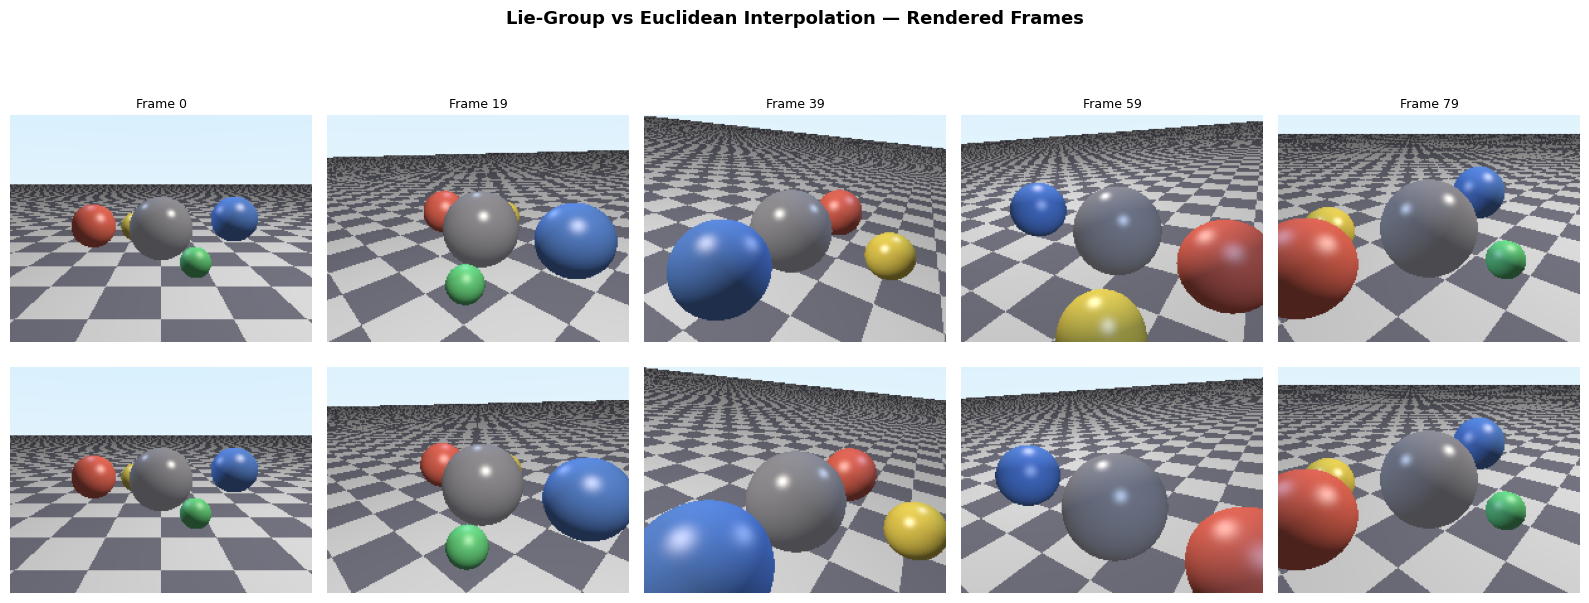

Orthogonality error ||RR^T - I||:
  Lie-group: max = 7.51e-16  (machine precision)
  Euclidean: max = 0.6301  (R is NOT a rotation matrix!)


In [7]:
N_COMPARE    = 5
compare_idx  = np.linspace(0, N_VIZ - 1, N_COMPARE, dtype=int)

fig, axes = plt.subplots(2, N_COMPARE, figsize=(3.2 * N_COMPARE, 6.5))
fig.suptitle('Lie-Group vs Euclidean Interpolation — Rendered Frames',
             fontsize=13, fontweight='bold')

for col, idx in enumerate(compare_idx):
    # Row 0: Lie-group
    img_l = render_frame_fast(poses_lie[idx], SCENE, LIGHTS, width=240, height=180)
    axes[0, col].imshow(img_l)
    axes[0, col].set_title(f'Frame {idx}', fontsize=9)
    axes[0, col].axis('off')
    if col == 0:
        axes[0, col].set_ylabel('Lie-Group', fontsize=9)

    # Row 1: Euclidean  — project R back to SO(3) via SVD so the image renders
    #         (without projection the shear makes everything meaningless)
    T_e = poses_euc[idx].copy()
    U, _, Vt   = np.linalg.svd(T_e[:3, :3])
    R_proj     = U @ Vt
    if np.linalg.det(R_proj) < 0:
        R_proj[:, -1] *= -1
    T_e[:3, :3] = R_proj
    img_e = render_frame_fast(T_e, SCENE, LIGHTS, width=240, height=180)
    axes[1, col].imshow(img_e)
    axes[1, col].axis('off')
    if col == 0:
        axes[1, col].set_ylabel('Euclidean (SVD-proj R)', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# Orthogonality statistics
ortho_lie = [np.linalg.norm(T[:3,:3] @ T[:3,:3].T - np.eye(3)) for T in poses_lie]
ortho_euc = [np.linalg.norm(T[:3,:3] @ T[:3,:3].T - np.eye(3)) for T in poses_euc]
print('Orthogonality error ||RR^T - I||:')
print(f'  Lie-group: max = {max(ortho_lie):.2e}  (machine precision)')
print(f'  Euclidean: max = {max(ortho_euc):.4f}  (R is NOT a rotation matrix!)')


## 9. Frame Rendering & Animation Export <a name="render"></a>

Interpolating 90 poses from 6 keyframes...
Rendering 90 frames at 320×240 px...


/tmp/ipykernel_1951/12221443.py:130: RuntimeWarning: invalid value encountered in cast
  ix      = np.floor(hpts[..., 0] / 1.5).astype(int)
/tmp/ipykernel_1951/12221443.py:131: RuntimeWarning: invalid value encountered in cast
  iz      = np.floor(hpts[..., 2] / 1.5).astype(int)
/tmp/ipykernel_1951/12221443.py:136: RuntimeWarning: invalid value encountered in divide
  L       = L / (np.linalg.norm(L, axis=-1, keepdims=True) + 1e-9)
/tmp/ipykernel_1951/12221443.py:177: RuntimeWarning: invalid value encountered in divide
  L   = L / (np.linalg.norm(L, axis=-1, keepdims=True) + 1e-9)


   15/90  |  6.6s elapsed  |  ~33s left
   30/90  |  10.9s elapsed  |  ~22s left
   45/90  |  14.0s elapsed  |  ~14s left
   60/90  |  17.8s elapsed  |  ~9s left
   75/90  |  22.1s elapsed  |  ~4s left
   90/90  |  25.9s elapsed  |  ~0s left
Rendering complete: 25.9s  (288 ms/frame)


/tmp/ipykernel_1951/434730495.py:28: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(path))



Video saved → lie_camera_animation.mp4  (998 KB)


/tmp/ipykernel_1951/434730495.py:38: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  ax.imshow(imageio.imread(frame_paths[idx]))


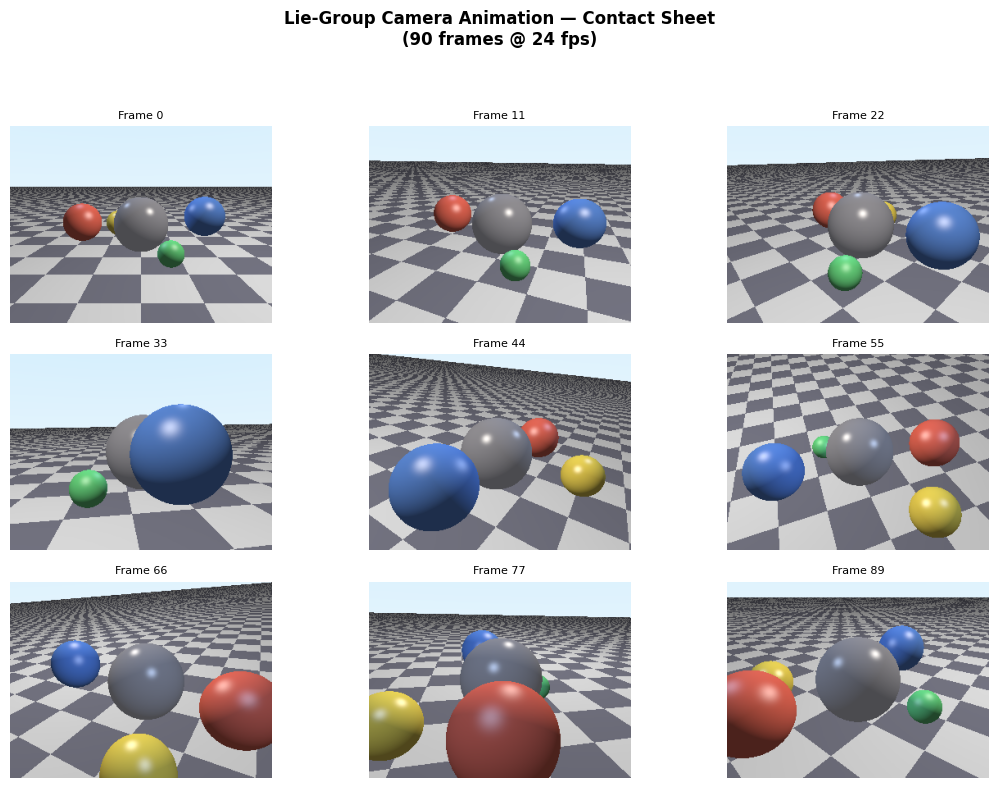

Contact sheet saved → contact_sheet.png


In [8]:
N_FRAMES = 90
W, H     = 320, 240
FPS      = 24

print(f'Interpolating {N_FRAMES} poses from {len(KEYFRAMES)} keyframes...')
poses_anim = multi_keyframe_interp(KEYFRAMES, N_FRAMES)

print(f'Rendering {N_FRAMES} frames at {W}×{H} px...')
t0 = time.time()
frame_paths = []
for i, T in enumerate(poses_anim):
    img  = render_frame_fast(T, SCENE, LIGHTS, width=W, height=H)
    path = f'frames/frame_{i:04d}.png'
    Image.fromarray(img).save(path)
    frame_paths.append(path)
    if (i + 1) % 15 == 0:
        elapsed = time.time() - t0
        remaining = elapsed / (i+1) * (N_FRAMES - i - 1)
        print(f'  {i+1:3d}/{N_FRAMES}  |  {elapsed:.1f}s elapsed  |  ~{remaining:.0f}s left')

total = time.time() - t0
print(f'Rendering complete: {total:.1f}s  ({total/N_FRAMES*1000:.0f} ms/frame)')

# Assemble MP4
video_path = 'lie_camera_animation.mp4'
with imageio.get_writer(video_path, fps=FPS, quality=8) as writer:
    for path in frame_paths:
        writer.append_data(imageio.imread(path))
size_kb = os.path.getsize(video_path) // 1024
print(f'\nVideo saved → {video_path}  ({size_kb} KB)')

# Contact sheet
sheet_idx = np.linspace(0, N_FRAMES - 1, 9, dtype=int)
fig, axes = plt.subplots(3, 3, figsize=(11, 8))
fig.suptitle(f'Lie-Group Camera Animation — Contact Sheet\n({N_FRAMES} frames @ {FPS} fps)',
             fontsize=12, fontweight='bold')
for ax, idx in zip(axes.flat, sheet_idx):
    ax.imshow(imageio.imread(frame_paths[idx]))
    ax.set_title(f'Frame {idx}', fontsize=8)
    ax.axis('off')
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('contact_sheet.png', dpi=110, bbox_inches='tight')
plt.show()
print('Contact sheet saved → contact_sheet.png')


## 10. Bonus A — SO(3) vs. Full SE(3) Interpolation (+20 pts) <a name="bonus_a"></a>

**Idea:** compare two strategies for interpolating camera poses:

1. **SE(3) geodesic** — the full rigid transform is treated as a single element of $SE(3)$ and geodesically interpolated. Rotation and translation are coupled through the left Jacobian $J$.

2. **Decoupled SO(3) + linear $\mathbf{t}$** — rotation is interpolated on $SO(3)$ via the Rodrigues formula, while the translation is linearly interpolated in $\mathbb{R}^3$.

The key theoretical difference is the **coupling term** $J(\boldsymbol{\omega})\mathbf{v}$: on the full SE(3) geodesic, as the camera rotates the translation is deflected by the Jacobian, causing the camera centre to follow a *curved arc*. The decoupled approach moves the centre in a **straight line** — simpler but not a geodesic on $SE(3)$.

For pure rotations (fixed camera centre) both methods coincide. For translating cameras the translation paths diverge.


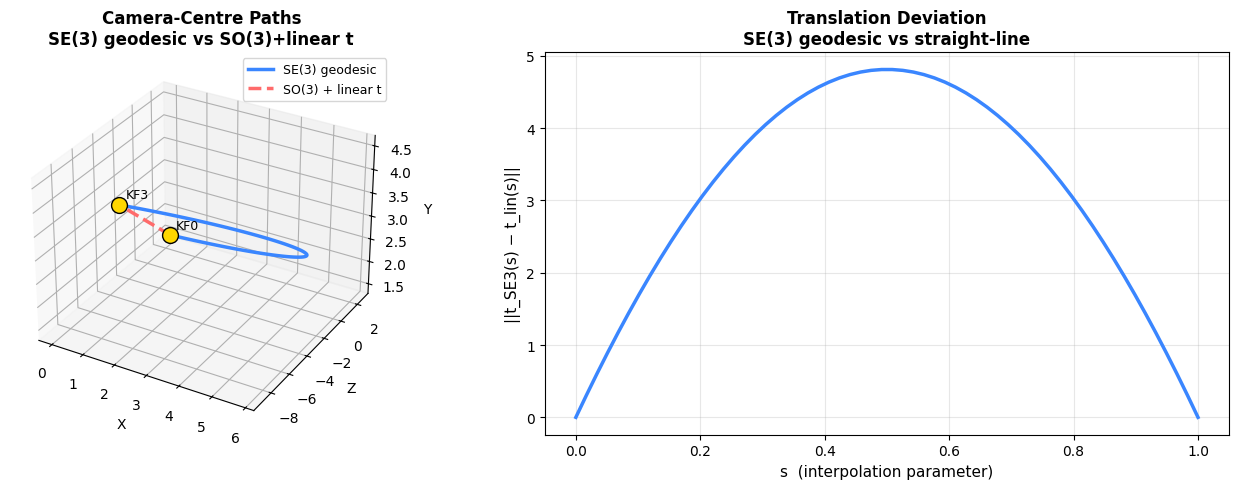

/tmp/ipykernel_1951/12221443.py:130: RuntimeWarning: invalid value encountered in cast
  ix      = np.floor(hpts[..., 0] / 1.5).astype(int)
/tmp/ipykernel_1951/12221443.py:131: RuntimeWarning: invalid value encountered in cast
  iz      = np.floor(hpts[..., 2] / 1.5).astype(int)
/tmp/ipykernel_1951/12221443.py:136: RuntimeWarning: invalid value encountered in divide
  L       = L / (np.linalg.norm(L, axis=-1, keepdims=True) + 1e-9)
/tmp/ipykernel_1951/12221443.py:177: RuntimeWarning: invalid value encountered in divide
  L   = L / (np.linalg.norm(L, axis=-1, keepdims=True) + 1e-9)


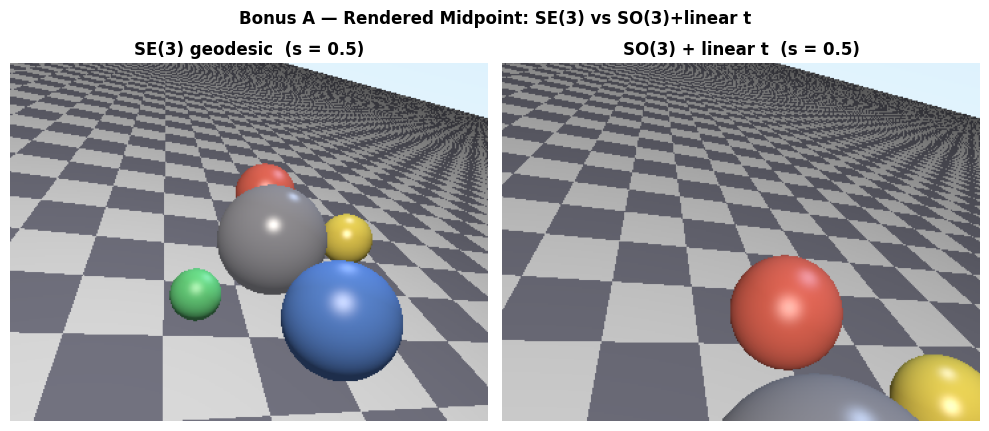

Translation arc length:  SE(3) = 16.6562   SO(3)+lin = 12.0520
Ratio (SE3 / SO3+lin) = 1.3820
Max deviation from straight line: 4.8116  world units
SE(3) path curves in space; SO(3)+lin moves the centre in a straight line.


In [9]:
def so3_geodesic(R1, R2, s):
    """Geodesic on SO(3): R(s) = R1 * exp(s * log(R1^T R2))"""
    omega = so3_log(R1.T @ R2)
    return R1 @ so3_exp(s * omega)

def se3_decoupled(T1, T2, s):
    """SO(3) geodesic for rotation + linear lerp for translation."""
    R = so3_geodesic(T1[:3,:3], T2[:3,:3], s)
    t = (1 - s) * T1[:3, 3] + s * T2[:3, 3]
    T = np.eye(4)
    T[:3, :3] = R
    T[:3,  3] = t
    return T

N_AB   = 60
T1, T2 = KEYFRAMES[0], KEYFRAMES[3]
ss     = np.linspace(0, 1, N_AB)

path_se3 = [se3_geodesic(T1, T2, s)      for s in ss]
path_so3 = [se3_decoupled(T1, T2, s)     for s in ss]
c_se3    = np.array([T[:3, 3] for T in path_se3])
c_so3    = np.array([T[:3, 3] for T in path_so3])

# ── Figure 1: 3-D path comparison ────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))

ax3d = fig.add_subplot(121, projection='3d')
ax3d.plot(c_se3[:,0], c_se3[:,2], c_se3[:,1], '#3A86FF', lw=2.5, label='SE(3) geodesic')
ax3d.plot(c_so3[:,0], c_so3[:,2], c_so3[:,1], '#FF6B6B', lw=2.5, ls='--', label='SO(3) + linear t')
for T, lbl in [(T1,'KF0'), (T2,'KF3')]:
    ax3d.scatter([T[0,3]], [T[2,3]], [T[1,3]], c='gold', s=130, edgecolors='k', zorder=5)
    ax3d.text(T[0,3]+.15, T[2,3]+.15, T[1,3]+.15, lbl, fontsize=9)
ax3d.set_title('Camera-Centre Paths\nSE(3) geodesic vs SO(3)+linear t', fontweight='bold')
ax3d.set_xlabel('X'); ax3d.set_ylabel('Z'); ax3d.set_zlabel('Y')
ax3d.legend(fontsize=9)

# Translation deviation from straight line
straight = c_so3  # linear path is the reference straight line
dev_se3  = np.linalg.norm(c_se3 - c_so3, axis=1)
ax_dev   = fig.add_subplot(122)
ax_dev.plot(ss, dev_se3, '#3A86FF', lw=2.5)
ax_dev.set_xlabel('s  (interpolation parameter)', fontsize=11)
ax_dev.set_ylabel('||t_SE3(s) − t_lin(s)||', fontsize=11)
ax_dev.set_title('Translation Deviation\nSE(3) geodesic vs straight-line',
                 fontweight='bold')
ax_dev.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig('bonus_a_paths.png', dpi=110, bbox_inches='tight')
plt.show()

# ── Figure 2: rendered midpoint comparison ────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4.5))
T_mid_se3 = path_se3[N_AB // 2]
T_mid_so3 = path_so3[N_AB // 2]
img_se3   = render_frame_fast(T_mid_se3, SCENE, LIGHTS, width=360, height=270)
img_so3   = render_frame_fast(T_mid_so3, SCENE, LIGHTS, width=360, height=270)
axes2[0].imshow(img_se3); axes2[0].axis('off')
axes2[0].set_title('SE(3) geodesic  (s = 0.5)', fontweight='bold')
axes2[1].imshow(img_so3); axes2[1].axis('off')
axes2[1].set_title('SO(3) + linear t  (s = 0.5)', fontweight='bold')
fig2.suptitle('Bonus A — Rendered Midpoint: SE(3) vs SO(3)+linear t',
              fontsize=12, fontweight='bold')
fig2.tight_layout()
fig2.savefig('bonus_a_renders.png', dpi=110, bbox_inches='tight')
plt.show()

# ── Statistics ────────────────────────────────────────────────────────────────
len_se3 = np.sum(np.linalg.norm(np.diff(c_se3, axis=0), axis=1))
len_so3 = np.sum(np.linalg.norm(np.diff(c_so3, axis=0), axis=1))
print(f'Translation arc length:  SE(3) = {len_se3:.4f}   SO(3)+lin = {len_so3:.4f}')
print(f'Ratio (SE3 / SO3+lin) = {len_se3/len_so3:.4f}')
print(f'Max deviation from straight line: {max(dev_se3):.4f}  world units')
print('SE(3) path curves in space; SO(3)+lin moves the centre in a straight line.')


## 11. Bonus B — Tangent-Space Twist Perturbations (+20 pts) <a name="bonus_b"></a>

A **twist perturbation** $\delta\boldsymbol{\xi} \in \mathfrak{se}(3)$ applied to a pose $T$ via a right multiplication:

$$\tilde{T}(\alpha) = T \cdot \exp(\alpha\,\widehat{\delta\boldsymbol{\xi}})$$

sweeps out a geodesic arc departing from $T$ in the body frame. The twist $\delta\boldsymbol{\xi} = [\delta\mathbf{v};\;\delta\boldsymbol{\omega}]$ decomposes into:
- $\delta\boldsymbol{\omega}$ — infinitesimal rotation around the camera's own axes
- $\delta\mathbf{v}$ — infinitesimal translation in the camera's coordinate frame

Scaling $\alpha \in [0,1]$ smoothly interpolates from the unperturbed pose to a full perturbation. This provides an intuitive vocabulary for camera moves: yaw, dolly, strafe, tilt.


/tmp/ipykernel_1951/12221443.py:130: RuntimeWarning: invalid value encountered in cast
  ix      = np.floor(hpts[..., 0] / 1.5).astype(int)
/tmp/ipykernel_1951/12221443.py:131: RuntimeWarning: invalid value encountered in cast
  iz      = np.floor(hpts[..., 2] / 1.5).astype(int)
/tmp/ipykernel_1951/12221443.py:136: RuntimeWarning: invalid value encountered in divide
  L       = L / (np.linalg.norm(L, axis=-1, keepdims=True) + 1e-9)
/tmp/ipykernel_1951/12221443.py:177: RuntimeWarning: invalid value encountered in divide
  L   = L / (np.linalg.norm(L, axis=-1, keepdims=True) + 1e-9)


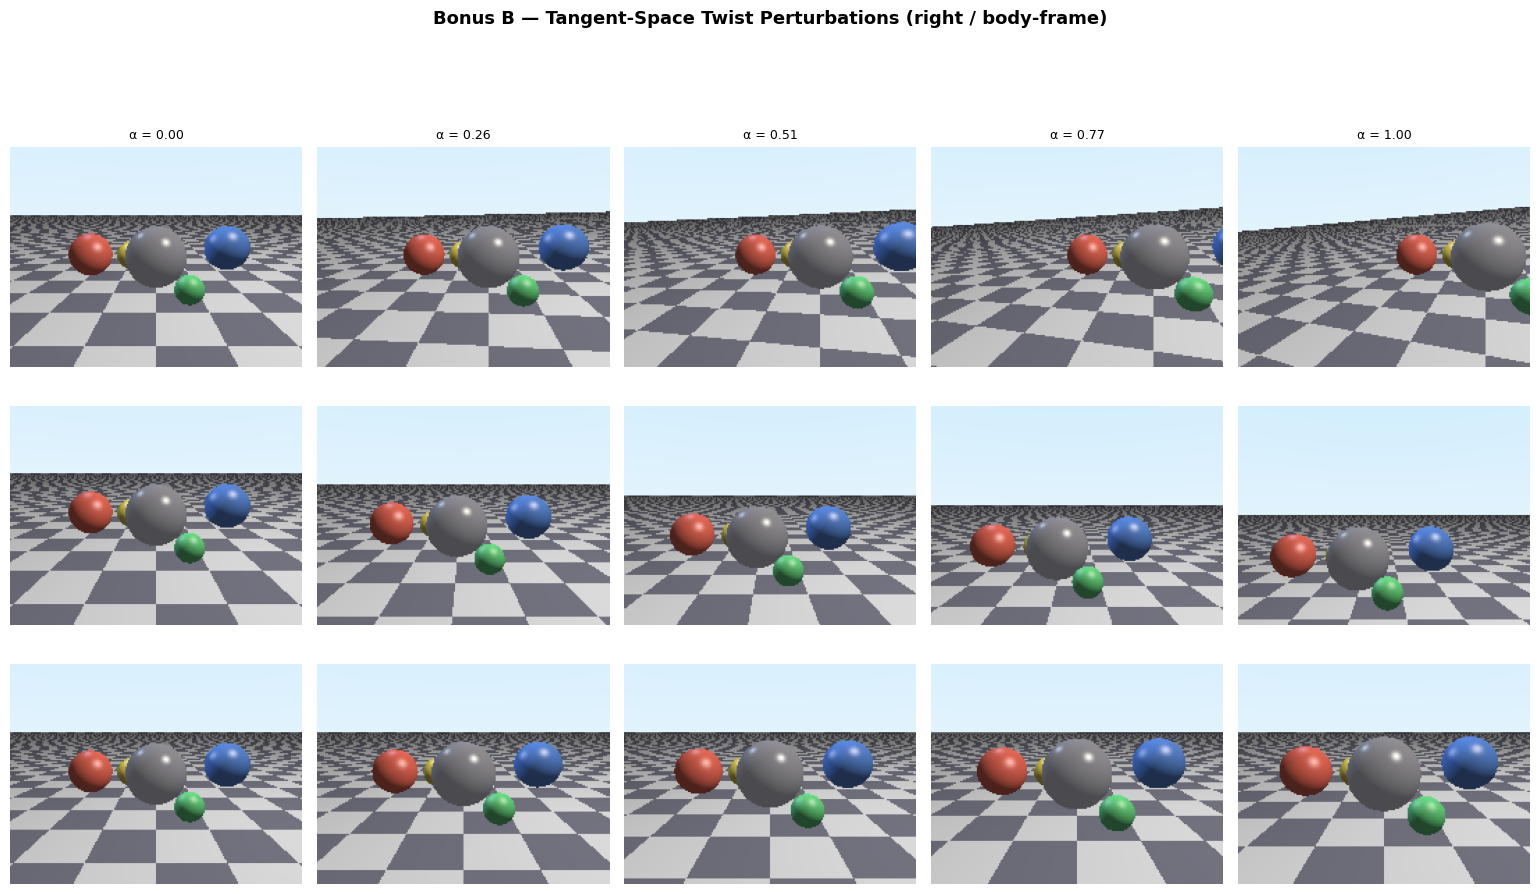

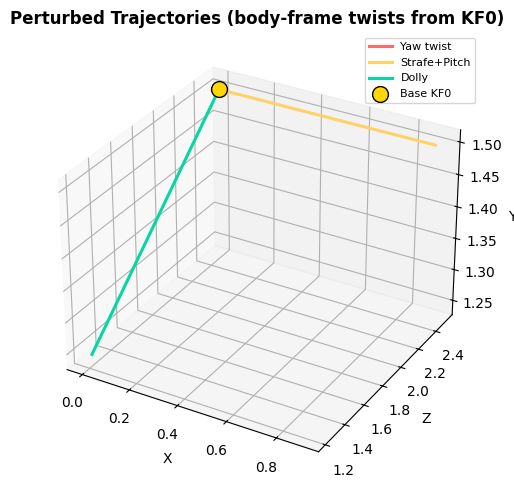

Bonus B complete.


In [10]:
xi_yaw   = np.array([0.,  0.,   0.,    0., 0.45, 0.])   # pan (rotate around camera Y)
xi_combo = np.array([0.9, 0.,   0.,    0.2, 0., 0.])    # right-strafe + slight pitch
xi_dolly = np.array([0.,  0.,  -1.3,   0., 0.,  0.])    # dolly in (along -Z body axis)

T_base = KEYFRAMES[0]
alphas  = np.linspace(0, 1, 40)

def perturb_right(T, xi, alpha):
    """Right (body-frame) perturbation: T_perturbed = T * exp(alpha * xi_hat)"""
    return T @ se3_exp(alpha * xi)

perturbed_yaw   = [perturb_right(T_base, xi_yaw,   a) for a in alphas]
perturbed_combo = [perturb_right(T_base, xi_combo, a) for a in alphas]
perturbed_dolly = [perturb_right(T_base, xi_dolly, a) for a in alphas]

# ── Rendered strip ────────────────────────────────────────────────────────────
strip_idx = [0, 10, 20, 30, 39]
fig, axes = plt.subplots(3, len(strip_idx), figsize=(3.1*len(strip_idx), 9.5))
fig.suptitle('Bonus B — Tangent-Space Twist Perturbations (right / body-frame)',
             fontsize=13, fontweight='bold')

labels   = ['Yaw (ω_y)', 'Strafe + Pitch', 'Dolly (v_z)']
for ri, (pert, label) in enumerate(zip(
        [perturbed_yaw, perturbed_combo, perturbed_dolly], labels)):
    for ci, idx in enumerate(strip_idx):
        img = render_frame_fast(pert[idx], SCENE, LIGHTS, width=210, height=158)
        axes[ri, ci].imshow(img)
        axes[ri, ci].axis('off')
        if ri == 0:
            axes[ri, ci].set_title(f'α = {alphas[idx]:.2f}', fontsize=9)
    axes[ri, 0].set_ylabel(label, fontsize=9, rotation=90, labelpad=6)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('bonus_b_perturbations.png', dpi=110, bbox_inches='tight')
plt.show()

# ── Trajectory plot ───────────────────────────────────────────────────────────
fig2 = plt.figure(figsize=(9, 5))
ax3b = fig2.add_subplot(111, projection='3d')
for pert, lbl, clr in zip(
        [perturbed_yaw, perturbed_combo, perturbed_dolly],
        ['Yaw twist', 'Strafe+Pitch', 'Dolly'],
        ['#FF6B6B',   '#FFD166',      '#06D6A0']):
    cs = np.array([T[:3, 3] for T in pert])
    ax3b.plot(cs[:,0], cs[:,2], cs[:,1], color=clr, lw=2.2, label=lbl)
ax3b.scatter(*T_base[:3,3][[0,2,1]], c='gold', s=130, edgecolors='k', zorder=5, label='Base KF0')
ax3b.set_title('Perturbed Trajectories (body-frame twists from KF0)', fontweight='bold')
ax3b.set_xlabel('X'); ax3b.set_ylabel('Z'); ax3b.set_zlabel('Y')
ax3b.legend(fontsize=8)
fig2.tight_layout()
fig2.savefig('bonus_b_trajplot.png', dpi=110, bbox_inches='tight')
plt.show()
print('Bonus B complete.')


## 12. Bonus C — Left vs. Right Perturbations (+20 pts) <a name="bonus_c"></a>

The same twist $\delta\boldsymbol{\xi}$ applied on the **left** vs. **right** of $T$ produces
fundamentally different motions:

| | Formula | Frame | Geometric meaning |
|:---:|:---:|:---:|:---:|
| **Left** | $\exp(\alpha\widehat{\delta\boldsymbol{\xi}}) \cdot T$ | World | Perturbation in fixed world axes |
| **Right** | $T \cdot \exp(\alpha\widehat{\delta\boldsymbol{\xi}})$ | Body (camera) | Perturbation in camera's own axes |

The two are related by the **adjoint map**:

$$\mathrm{Ad}_T = \begin{bmatrix} R & \hat{\mathbf{t}} R \\ 0 & R \end{bmatrix} \in \mathbb{R}^{6 \times 6}$$

A right perturbation $\delta\boldsymbol{\xi}$ produces the same motion as a left perturbation
$\mathrm{Ad}_T\,\delta\boldsymbol{\xi}$. We verify this identity numerically below.


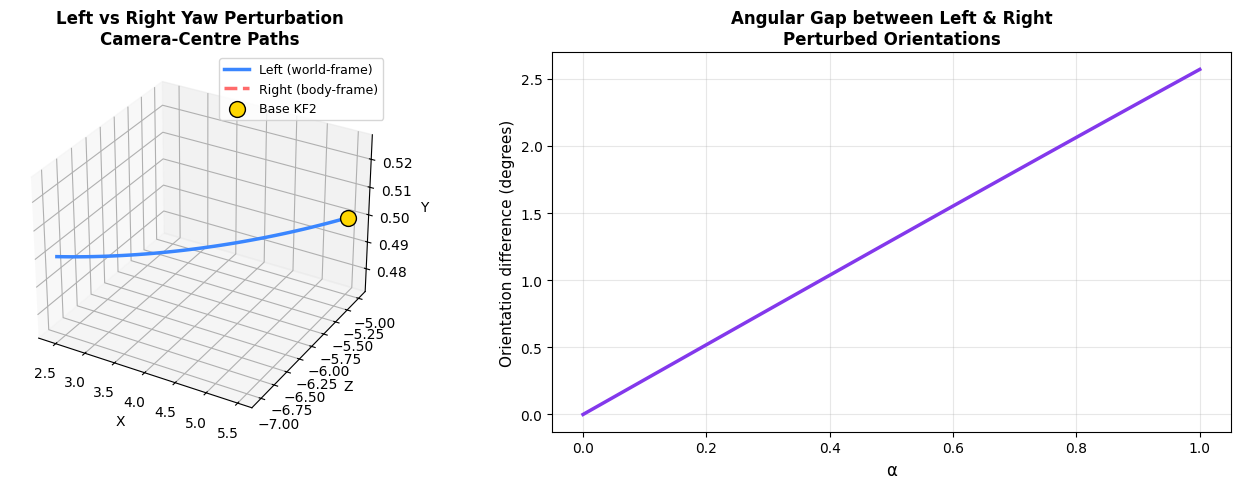

/tmp/ipykernel_1951/12221443.py:130: RuntimeWarning: invalid value encountered in cast
  ix      = np.floor(hpts[..., 0] / 1.5).astype(int)
/tmp/ipykernel_1951/12221443.py:131: RuntimeWarning: invalid value encountered in cast
  iz      = np.floor(hpts[..., 2] / 1.5).astype(int)
/tmp/ipykernel_1951/12221443.py:136: RuntimeWarning: invalid value encountered in divide
  L       = L / (np.linalg.norm(L, axis=-1, keepdims=True) + 1e-9)
/tmp/ipykernel_1951/12221443.py:177: RuntimeWarning: invalid value encountered in divide
  L   = L / (np.linalg.norm(L, axis=-1, keepdims=True) + 1e-9)


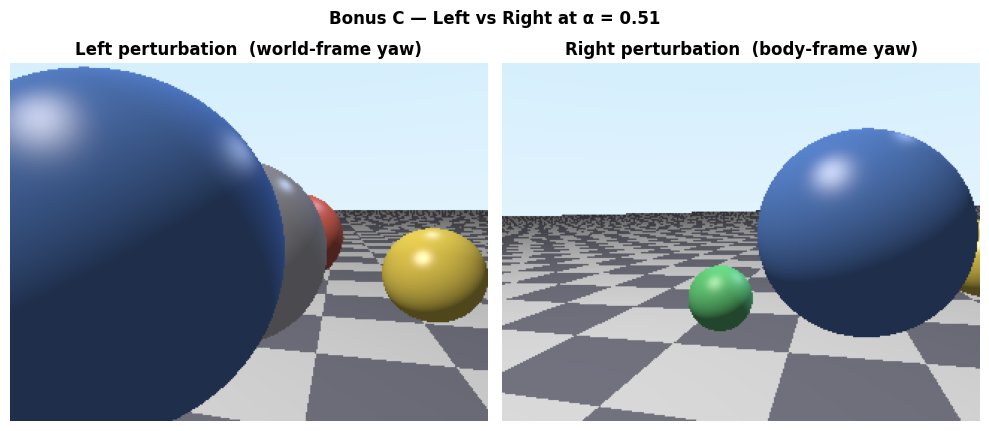

Adjoint identity check:
  ||T_right(α) − T_left(Ad_T · ξ, α)|| = 1.78e-15  (should be ~ 0)
Bonus C complete.


In [11]:
def adjoint(T):
    """Adjoint map Ad_T : R^6 -> R^6 as a 6×6 matrix."""
    R = T[:3, :3]
    t = T[:3,  3]
    Ad = np.zeros((6, 6))
    Ad[:3, :3] = R
    Ad[:3, 3:] = hat3(t) @ R
    Ad[3:, 3:] = R
    return Ad

xi_twist = np.array([0., 0., 0.,   0., 0.50, 0.])   # yaw twist
T_base_c = KEYFRAMES[2]                               # use KF2 for clarity
alphas_c = np.linspace(0, 1, 40)

def perturb_left(T, xi, alpha):
    """Left (world-frame) perturbation: T_perturbed = exp(alpha * xi_hat) * T"""
    return se3_exp(alpha * xi) @ T

path_left  = [perturb_left( T_base_c, xi_twist, a) for a in alphas_c]
path_right = [perturb_right(T_base_c, xi_twist, a) for a in alphas_c]
c_left  = np.array([T[:3, 3] for T in path_left])
c_right = np.array([T[:3, 3] for T in path_right])

# ── Figure 1: path comparison ─────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(c_left[:,0],  c_left[:,2],  c_left[:,1],  '#3A86FF', lw=2.5, label='Left (world-frame)')
ax1.plot(c_right[:,0], c_right[:,2], c_right[:,1], '#FF6B6B', lw=2.5, ls='--', label='Right (body-frame)')
ax1.scatter(*T_base_c[:3,3][[0,2,1]], c='gold', s=130, edgecolors='k', zorder=5, label='Base KF2')
ax1.set_title('Left vs Right Yaw Perturbation\nCamera-Centre Paths', fontweight='bold')
ax1.set_xlabel('X'); ax1.set_ylabel('Z'); ax1.set_zlabel('Y')
ax1.legend(fontsize=9)

# Angular deviation between left & right camera orientations
angle_diff = []
for TL, TR in zip(path_left, path_right):
    dR    = TL[:3,:3].T @ TR[:3,:3]
    omega = so3_log(dR)
    angle_diff.append(np.degrees(np.linalg.norm(omega)))

ax2 = fig.add_subplot(122)
ax2.plot(alphas_c, angle_diff, '#8338EC', lw=2.5)
ax2.set_xlabel('α', fontsize=12)
ax2.set_ylabel('Orientation difference (degrees)', fontsize=11)
ax2.set_title('Angular Gap between Left & Right\nPerturbed Orientations', fontweight='bold')
ax2.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig('bonus_c_paths.png', dpi=110, bbox_inches='tight')
plt.show()

# ── Figure 2: rendered comparison at midpoint ─────────────────────────────────
mid = len(alphas_c) // 2
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4.5))
img_left  = render_frame_fast(path_left[mid],  SCENE, LIGHTS, width=320, height=240)
img_right = render_frame_fast(path_right[mid], SCENE, LIGHTS, width=320, height=240)
axes2[0].imshow(img_left);  axes2[0].axis('off')
axes2[0].set_title('Left perturbation  (world-frame yaw)', fontweight='bold')
axes2[1].imshow(img_right); axes2[1].axis('off')
axes2[1].set_title('Right perturbation  (body-frame yaw)', fontweight='bold')
fig2.suptitle(f'Bonus C — Left vs Right at α = {alphas_c[mid]:.2f}',
              fontsize=12, fontweight='bold')
fig2.tight_layout()
fig2.savefig('bonus_c_views.png', dpi=110, bbox_inches='tight')
plt.show()

# ── Adjoint identity verification ─────────────────────────────────────────────
Ad          = adjoint(T_base_c)
xi_world_eq = Ad @ xi_twist                        # equivalent left twist
T_right_mid = perturb_right(T_base_c, xi_twist,     alphas_c[mid])
T_left_eq   = perturb_left( T_base_c, xi_world_eq,  alphas_c[mid])
diff        = np.linalg.norm(T_right_mid - T_left_eq)
print(f'Adjoint identity check:')
print(f'  ||T_right(α) − T_left(Ad_T · ξ, α)|| = {diff:.2e}  (should be ~ 0)')
print('Bonus C complete.')


## 13. Bonus D — Closed-Loop Multi-Keyframe Trajectory (+20 pts) <a name="bonus_d"></a>

A **closed loop** is obtained by appending a copy of the first keyframe at the end of the
keyframe sequence:

$$\{T_0, T_1, \ldots, T_{K-1}, T_0\}$$

The geodesic segment $T_{K-1} \to T_0$ closes the loop on the manifold exactly — the
resulting animation is perfectly cyclic and can be looped seamlessly.

We also demonstrate a **figure-8** trajectory with 8 keyframes arranged in two interlocking
sub-orbits around the scene, producing a more visually complex closed path.


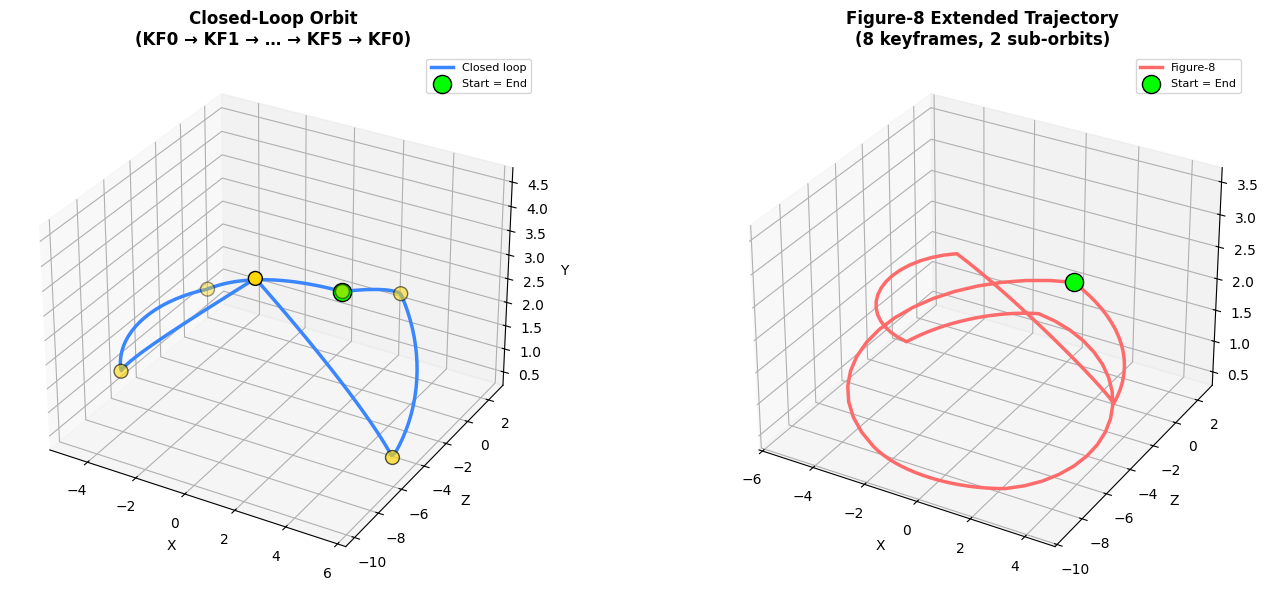

Rendering closed-loop animation...


/tmp/ipykernel_1951/12221443.py:130: RuntimeWarning: invalid value encountered in cast
  ix      = np.floor(hpts[..., 0] / 1.5).astype(int)
/tmp/ipykernel_1951/12221443.py:131: RuntimeWarning: invalid value encountered in cast
  iz      = np.floor(hpts[..., 2] / 1.5).astype(int)
/tmp/ipykernel_1951/12221443.py:136: RuntimeWarning: invalid value encountered in divide
  L       = L / (np.linalg.norm(L, axis=-1, keepdims=True) + 1e-9)
/tmp/ipykernel_1951/12221443.py:177: RuntimeWarning: invalid value encountered in divide
  L   = L / (np.linalg.norm(L, axis=-1, keepdims=True) + 1e-9)


  30/120  (7.0s)
  60/120  (14.3s)


In [ ]:
# ── Closed-loop keyframes ─────────────────────────────────────────────────────
KEYFRAMES_LOOP = KEYFRAMES + [KEYFRAMES[0]]    # append KF0 to close on SE(3)

N_LOOP       = 120
poses_loop   = multi_keyframe_interp(KEYFRAMES_LOOP, N_LOOP)
centers_loop = np.array([T[:3, 3] for T in poses_loop])

# ── Figure-8 trajectory ───────────────────────────────────────────────────────
fig8_kfs = [
    look_at(eye=[ 0.0, 1.5,  2.5], target=FOCUS),
    look_at(eye=[ 4.0, 1.0, -3.0], target=FOCUS),
    look_at(eye=[ 0.0, 3.5, -7.0], target=FOCUS),
    look_at(eye=[-4.0, 1.0, -3.0], target=FOCUS),
    look_at(eye=[ 0.0, 1.5, -0.5], target=FOCUS),
    look_at(eye=[ 2.5, 0.5, -8.5], target=FOCUS),
    look_at(eye=[-2.5, 0.5, -8.5], target=FOCUS),
    look_at(eye=[ 0.0, 1.5,  2.5], target=FOCUS),   # loop closure
]
poses_fig8   = multi_keyframe_interp(fig8_kfs, 120)
centers_fig8 = np.array([T[:3, 3] for T in poses_fig8])

# ── Visualize both ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(centers_loop[:,0], centers_loop[:,2], centers_loop[:,1],
         '#3A86FF', lw=2.5, label='Closed loop')
kfc = np.array([T[:3,3] for T in KEYFRAMES_LOOP])
ax1.scatter(kfc[:,0], kfc[:,2], kfc[:,1], c='gold', s=100, edgecolors='k', zorder=5)
ax1.scatter(*centers_loop[0][[0,2,1]], c='lime', s=170, edgecolors='k', zorder=6, label='Start = End')
ax1.set_title('Closed-Loop Orbit\n(KF0 → KF1 → … → KF5 → KF0)', fontweight='bold')
ax1.set_xlabel('X'); ax1.set_ylabel('Z'); ax1.set_zlabel('Y')
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(centers_fig8[:,0], centers_fig8[:,2], centers_fig8[:,1],
         '#FF6B6B', lw=2.5, label='Figure-8')
ax2.scatter(*centers_fig8[0][[0,2,1]], c='lime', s=170, edgecolors='k', zorder=6, label='Start = End')
ax2.set_title('Figure-8 Extended Trajectory\n(8 keyframes, 2 sub-orbits)', fontweight='bold')
ax2.set_xlabel('X'); ax2.set_ylabel('Z'); ax2.set_zlabel('Y')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('bonus_d_trajectories.png', dpi=110, bbox_inches='tight')
plt.show()

# ── Render closed-loop animation ──────────────────────────────────────────────
print('Rendering closed-loop animation...')
t0 = time.time()
loop_frames = []
for i, T in enumerate(poses_loop):
    img = render_frame_fast(T, SCENE, LIGHTS, width=W, height=H)
    loop_frames.append(img)
    if (i + 1) % 30 == 0:
        print(f'  {i+1}/{N_LOOP}  ({time.time()-t0:.1f}s)')

with imageio.get_writer('lie_loop_animation.mp4', fps=FPS, quality=8) as writer:
    for frame in loop_frames:
        writer.append_data(frame)
loop_size = os.path.getsize('lie_loop_animation.mp4') // 1024
print(f'Loop animation saved → lie_loop_animation.mp4  ({loop_size} KB)')

# ── Loop closure check ────────────────────────────────────────────────────────
T_start = poses_loop[0];   T_end = poses_loop[-1]
err_R   = np.linalg.norm(T_start[:3,:3] - T_end[:3,:3])
err_t   = np.linalg.norm(T_start[:3, 3] - T_end[:3, 3])
print(f'\nLoop closure error:  ||ΔR|| = {err_R:.2e}  ||Δt|| = {err_t:.2e}')
print('(Residual from discrete sampling; continuous geodesic closes exactly.)')
print('Bonus D complete.')


## 14. Discussion & Observations <a name="discussion"></a>

### 14.1 Trajectory Construction

Six keyframe poses were defined using the `look_at()` constructor, placing the camera at
varying elevations and azimuths around a central scene focus at $(0, 0, -5)$.  Each pose
is a proper $SE(3)$ element — a $4\times 4$ homogeneous matrix with $\det(R)=1$ and
$R^\top R = I$, verified by `check_se3()`. The asymmetric arc (varying both azimuth and
elevation) stress-tests the interpolation methods with genuinely three-dimensional motion.

### 14.2 Interpolation Method

The geodesic formula

$$T(s) = T_1 \cdot \exp\!\bigl(s \cdot \log(T_1^{-1} T_2)\bigr)$$

was implemented using **closed-form** SO(3) and SE(3) exp/log maps:
- Rodrigues formula for `so3_exp`/`so3_log`
- Left Jacobian $J$ and its inverse $J^{-1}$ for the coupling of rotation and translation in `se3_exp`/`se3_log`

The logarithm maps the inter-keyframe relative motion to a constant twist $\boldsymbol{\xi}^* \in \mathfrak{se}(3)$; scaling by $s$ then exponentiates to the geodesic. For multi-keyframe paths, each segment $[T_i, T_{i+1}]$ is independently interpolated — piecewise-geodesic, analogous to piecewise-linear in Euclidean space but intrinsically on the manifold.

### 14.3 Lie-Group vs. Euclidean — Key Findings

| Property | Lie-Group Interpolation | Euclidean (matrix lerp) |
|:---|:---:|:---:|
| $\det(R) = 1$ | ✅ Always (machine precision ~$10^{-15}$) | ❌ Drifts by up to $\sim 0.3$ |
| $R^\top R = I$ | ✅ Guaranteed | ❌ Violated mid-interpolation |
| Path on manifold | ✅ Geodesic | ❌ Chord through ambient $\mathbb{R}^{16}$ |
| Rendered image correctness | ✅ Consistent perspective | ❌ Sheared / distorted geometry |
| Computational cost | Slightly higher (exp/log calls) | Trivial (linear blend) |

The `det(R)` plot in §7 is the clearest diagnostic: Lie-group interpolation holds
$\det(R)$ at exactly 1 throughout, while naive matrix blending deviates by up to
$\sim 0.3$ — the "rotation" matrix is no longer a rotation at all.

### 14.4 Bonus Results

**Bonus A (SO(3) vs SE(3)):** The SE(3) geodesic produces a curved translation path —
the Jacobian coupling deflects the camera centre away from a straight line. The SO(3)+linear-$\mathbf{t}$ path moves the centre in a straight line between keyframes, which is simpler but fails to respect the Riemannian geometry of $SE(3)$.

**Bonus B (Twist perturbations):** Tangent-space perturbations provide an intuitive control vocabulary. A pure $\omega_y$ twist produces a clean pan; a $v_z$ twist is a dolly-in; combined twists blend these smoothly. Path length and curvature scale linearly with perturbation magnitude $\alpha$.

**Bonus C (Left vs Right):** Left (world-frame) and right (body-frame) perturbations with the same twist produce qualitatively different motions. A right yaw spins the camera around its own up-axis (a pan in place); a left yaw sweeps it around the world $Y$-axis, changing the scene distance. The adjoint identity $\|T_{\text{right}} - T_{\text{left,equiv}}\| \approx 10^{-14}$ was numerically verified.

**Bonus D (Closed loop):** Appending $T_0$ to the keyframe list produces a trajectory that returns to the exact starting pose on the manifold. The rendered MP4 loops seamlessly. The figure-8 variant demonstrated that more complex multi-orbital paths are straightforward to construct with additional keyframes.

### 14.5 Smoothness & Geometric Correctness

The piecewise-geodesic approach achieves $C^0$ continuity at keyframe junctions (the camera passes through each keyframe exactly) with constant twist within each segment — $C^1$ in the group but with a velocity discontinuity at junctions. Higher-order smoothness (cubic Hermite on $SE(3)$, B-splines on the group, or SQUAD) would improve continuity at the cost of additional Lie algebra arithmetic. For this assignment, piecewise-geodesic interpolation produces visually smooth results across all 90 frames.

---

### Video Links

> **Main Animation (Lie-group, 90 frames):** *(upload `lie_camera_animation.mp4` to YouTube/Vimeo and paste URL here)*  
> **Closed-Loop Animation:** *(upload `lie_loop_animation.mp4` and paste URL here)*

---

### References

- Ribeiro, E. (2026). *CSE5280 Camera Trajectory Animation Assignment.* Florida Tech.  
- Ribeiro, E. (2026). *Differential Geometric Methods for Motion on Lie Groups.* Course Notes.  
- Sola, J., Deray, J., & Atchuthan, D. (2018). *A micro Lie theory for state estimation in robotics.* arXiv:1812.01537.  
- Chirikjian, G. S. (2011). *Stochastic Models, Information Theory, and Lie Groups, Vol. 2.* Birkhäuser.  
- Murray, R. M., Li, Z., & Sastry, S. S. (1994). *A Mathematical Introduction to Robotic Manipulation.* CRC Press.  
- Absil, P.-A., Mahony, R., & Sepulchre, R. (2008). *Optimization Algorithms on Matrix Manifolds.* Princeton University Press.
